# NYC Data Job Tracker — EDA
Exploratory analysis to decide what goes on the Market Insights page.

**Questions to answer:**
1. Salary distributions — are they interesting by archetype? Enough data?
2. Tech stack — what's the top-N, is there meaningful spread?
3. Work model — remote vs hybrid vs onsite breakdown by archetype
4. Title inflation — any patterns by company or archetype?
5. Seniority inflation — how does inferred_seniority vs job_title diverge?
6. Posting trends — enough data points over time to show a trend?
7. Paradigms — any signal worth surfacing?


In [2]:
import sys
sys.path.insert(0, '..')  # so we can import from presentation/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from data_loader import load_fct_job_postings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

df = load_fct_job_postings()
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
df.dtypes

Loaded 112 rows, 31 columns


job_id                                  str
source                                  str
job_title                               str
company_name                            str
job_url                                 str
date_posted                   datetime64[s]
description                             str
city                                    str
state                                   str
country                                 str
latitude                            float64
longitude                           float64
work_model                              str
employment_type                         str
final_salary_min                    float64
final_salary_max                    float64
inferred_seniority                      str
role_archetype                          str
work_focus                              str
is_title_inflated                      bool
inflation_reasoning                     str
tech_stack_required                  object
tech_stack_preferred            

## 1. Dataset overview

In [3]:
# Null rates
null_rates = (df.isna().mean() * 100).sort_values(ascending=False)
print("Null rates (%):\n")
print(null_rates.to_string())

Null rates (%):

inflation_reasoning     85.714286
years_required_max      50.892857
final_salary_max        40.178571
final_salary_min        38.392857
years_required_min      24.107143
city                    12.500000
state                   12.500000
latitude                12.500000
longitude               12.500000
country                  7.142857
confidence_score         0.000000
enriched_at              0.000000
degree_requirement       0.000000
is_title_inflated        0.000000
paradigms_preferred      0.000000
paradigms_required       0.000000
tech_stack_preferred     0.000000
tech_stack_required      0.000000
job_id                   0.000000
work_focus               0.000000
role_archetype           0.000000
inferred_seniority       0.000000
source                   0.000000
employment_type          0.000000
work_model               0.000000
description              0.000000
date_posted              0.000000
job_url                  0.000000
company_name             0.0000

In [4]:
# Array column empty rates
array_cols = ['tech_stack_required', 'tech_stack_preferred', 'paradigms_required', 'paradigms_preferred']
for col in array_cols:
    empty = df[col].apply(lambda x: len(x) == 0 if isinstance(x, list) else True).mean()
    print(f"{col}: {empty:.1%} empty")

tech_stack_required: 8.9% empty
tech_stack_preferred: 48.2% empty
paradigms_required: 6.2% empty
paradigms_preferred: 48.2% empty


In [6]:
# Value counts for categorical fields
for col in ['source', 'role_archetype', 'work_model', 'employment_type', 'inferred_seniority', 'degree_requirement']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- source ---
source
jsearch       77
theirstack    18
builtin       17
Name: count, dtype: int64

--- role_archetype ---
role_archetype
data_analyst          73
analytics_engineer    15
data_engineer         14
hybrid                10
Name: count, dtype: int64

--- work_model ---
work_model
onsite    79
remote    23
hybrid    10
Name: count, dtype: int64

--- employment_type ---
employment_type
full_time    96
contract      9
other         5
part_time     2
Name: count, dtype: int64

--- inferred_seniority ---
inferred_seniority
mid       70
entry     28
senior    14
Name: count, dtype: int64

--- degree_requirement ---
degree_requirement
bachelors        54
none             36
equivalent_ok    18
masters           4
Name: count, dtype: int64


## 2. Salary analysis

In [8]:
sal_df = df.dropna(subset=['final_salary_min', 'final_salary_max']).copy()
sal_df['salary_midpoint'] = (sal_df['final_salary_min'] + sal_df['final_salary_max']) / 2
print(f"Rows with salary: {len(sal_df)} / {len(df)} ({len(sal_df)/len(df):.1%})")
print("\nSalary midpoint stats:")
print(sal_df['salary_midpoint'].describe())
print("\nOutliers (> $300k):")
print(sal_df[sal_df['salary_midpoint'] > 300_000][['job_title', 'company_name', 'final_salary_min', 'final_salary_max']])

Rows with salary: 67 / 112 (59.8%)

Salary midpoint stats:
count        67.000000
mean     117534.059701
std       66307.037486
min        2080.000000
25%       80000.000000
50%      100000.000000
75%      140200.000000
max      445000.000000
Name: salary_midpoint, dtype: float64

Outliers (> $300k):
                                          job_title  company_name  \
48                Security Analytics Engineer L4 35       Netflix   
61  Analytics Engineer (TakeUp), Mid-Level (Remote)  jobright.com   
69                       [P] Data Scientist, Policy     Anthropic   

    final_salary_min  final_salary_max  
48          250000.0          421000.0  
61          170000.0          720000.0  
69          275000.0          370000.0  


In [9]:
# Salary by archetype — is there enough data per group?
arch_sal = sal_df.groupby('role_archetype')['salary_midpoint'].agg(['count', 'median', 'mean', 'std'])
print(arch_sal)

                    count    median           mean            std
role_archetype                                                   
analytics_engineer      8  144125.0  201937.500000  120996.808547
data_analyst           46   90000.0  102284.391304   48115.765918
data_engineer           7  140000.0  129907.142857   41438.432529
hybrid                  6  118375.0  107475.000000   27728.212167


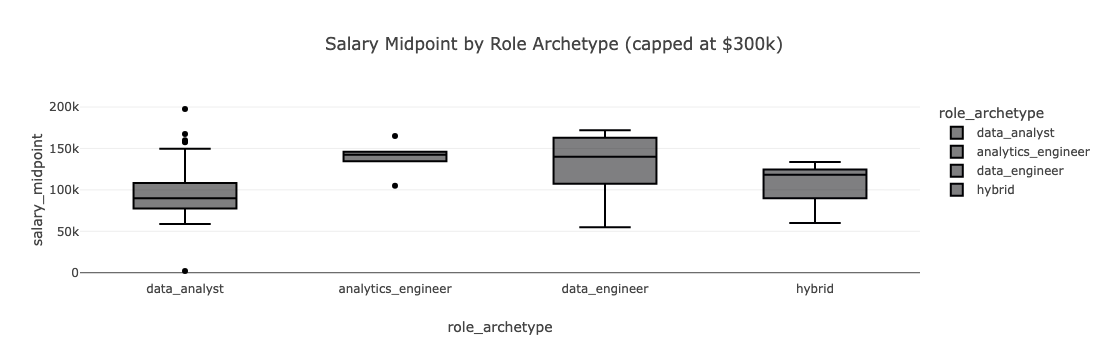

In [10]:
# Box plot — salary by archetype
# Cap at 300k to remove outlier distortion
fig = px.box(
    sal_df[sal_df['salary_midpoint'] <= 300_000],
    x='role_archetype',
    y='salary_midpoint',
    title='Salary Midpoint by Role Archetype (capped at $300k)',
    color='role_archetype',
)
fig.show()

## 3. Tech stack analysis

In [12]:
# Flatten and count required tech stack
all_required = [tech for row in df['tech_stack_required'] if isinstance(row, list) for tech in row]
all_preferred = [tech for row in df['tech_stack_preferred'] if isinstance(row, list) for tech in row]

req_counts = Counter(all_required)
pref_counts = Counter(all_preferred)

print(f"Unique required techs: {len(req_counts)}")
print(f"Unique preferred techs: {len(pref_counts)}")
print("\nTop 20 required:")
for tech, count in req_counts.most_common(20):
    print(f"  {count:3d}  {tech}")

Unique required techs: 126
Unique preferred techs: 109

Top 20 required:
   61  sql
   40  python
   36  excel
   15  power bi
   15  r
   11  tableau
   10  snowflake
   10  powerpoint
    7  word
    6  oracle
    5  etl
    4  sas
    4  access
    4  stata
    3  lookers
    3  aws
    3  outlook
    3  airflow
    3  pl/sql
    3  google sheets


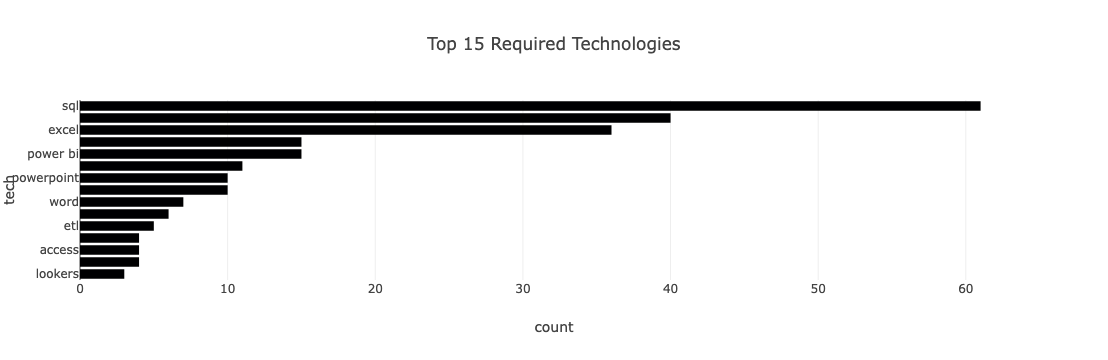

In [13]:
# Visualize top-N required tech
top_n = 15
tech_df = pd.DataFrame(req_counts.most_common(top_n), columns=['tech', 'count'])
fig = px.bar(
    tech_df.sort_values('count'),
    x='count', y='tech',
    orientation='h',
    title=f'Top {top_n} Required Technologies'
)
fig.show()

In [14]:
# Tech stack by archetype — which tools correlate with which roles?
for arch in df['role_archetype'].dropna().unique():
    arch_df = df[df['role_archetype'] == arch]
    techs = [t for row in arch_df['tech_stack_required'] if isinstance(row, list) for t in row]
    top = Counter(techs).most_common(10)
    print(f"\n{arch} (n={len(arch_df)}):")
    for tech, count in top:
        print(f"  {count:3d}  {tech}")


data_analyst (n=73):
   40  sql
   34  excel
   26  python
   14  power bi
   12  r
   10  powerpoint
    9  tableau
    7  word
    4  snowflake
    4  access

analytics_engineer (n=15):
   12  sql
    5  python
    2  snowflake
    2  redshift
    2  oracle
    2  nosql
    2  etl
    2  tableau
    2  quicksight
    2  r

data_engineer (n=14):
    8  python
    7  sql
    3  snowflake
    2  airflow
    2  aws
    1  postgresql
    1  presto
    1  kafka
    1  oracle
    1  etl

hybrid (n=10):
    2  sql
    1  edi
    1  python
    1  r
    1  github
    1  databricks
    1  snowflake
    1  plm
    1  ms office
    1  excel


## 4. Work model & employment type

work_model          hybrid  onsite  remote
role_archetype                            
analytics_engineer     6.7    73.3    20.0
data_analyst           9.6    69.9    20.5
data_engineer          0.0    78.6    21.4
hybrid                20.0    60.0    20.0


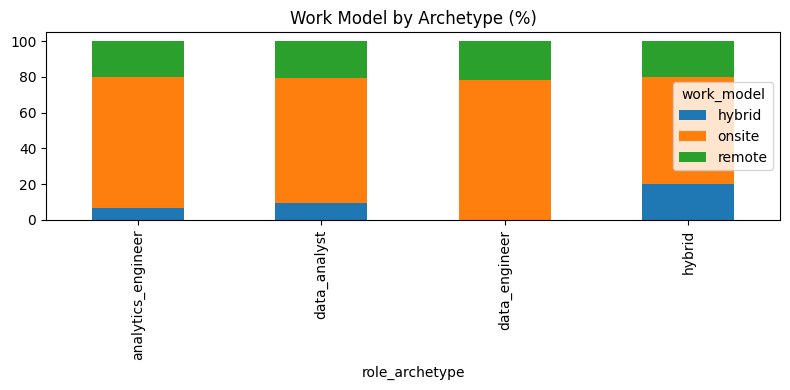

In [15]:
# Work model by archetype
wm_arch = df.groupby(['role_archetype', 'work_model']).size().unstack(fill_value=0)
wm_arch_pct = wm_arch.div(wm_arch.sum(axis=1), axis=0) * 100
print(wm_arch_pct.round(1))
wm_arch_pct.plot(kind='bar', stacked=True, figsize=(8, 4), title='Work Model by Archetype (%)')
plt.tight_layout()
plt.show()

## 5. Title inflation patterns

In [17]:
inflated = df[df['is_title_inflated'] == True]
print(f"Inflated: {len(inflated)} / {len(df)} ({len(inflated)/len(df):.1%})")
print("\nBy archetype:")
print(inflated['role_archetype'].value_counts())
print("\nBy company (top 10):")
print(inflated['company_name'].value_counts().head(10))
print("\nSample inflation reasoning:")
for _, row in inflated.dropna(subset=['inflation_reasoning']).head(5).iterrows():
    print(f"  [{row['job_title']}] {row['inflation_reasoning'][:120]}")

Inflated: 16 / 112 (14.3%)

By archetype:
role_archetype
data_analyst          6
data_engineer         5
analytics_engineer    3
hybrid                2
Name: count, dtype: int64

By company (top 10):
company_name
AmeriSave Mortgage               1
Kasmo Global                     1
NewYork-Presbyterian Hospital    1
Staffing the Universe            1
Kelly                            1
DriveWealth                      1
Jobs via Dice                    1
Legora                           1
Fiserv                           1
Crowe Global                     1
Name: count, dtype: int64

Sample inflation reasoning:
  [Capital Markets Data Engineer: Real-Time Analytics & Automation] The title suggests a senior role, but the responsibilities align with a senior level due to the required experience.
  [Data Engineering Position | REMOTE | Analytics] The title 'Data Architect' implies a higher level of seniority than the mid-level experience inferred from the requireme
  [Information Technolog

## 6. Posting trends over time

date_posted range: 2026-05-20 00:00:00 -> 2026-06-04 00:00:00
ingested_at range: 2026-05-25 19:04:42.599092+00:00 -> 2026-06-04 12:04:35.529167+00:00
Null date_posted: 0


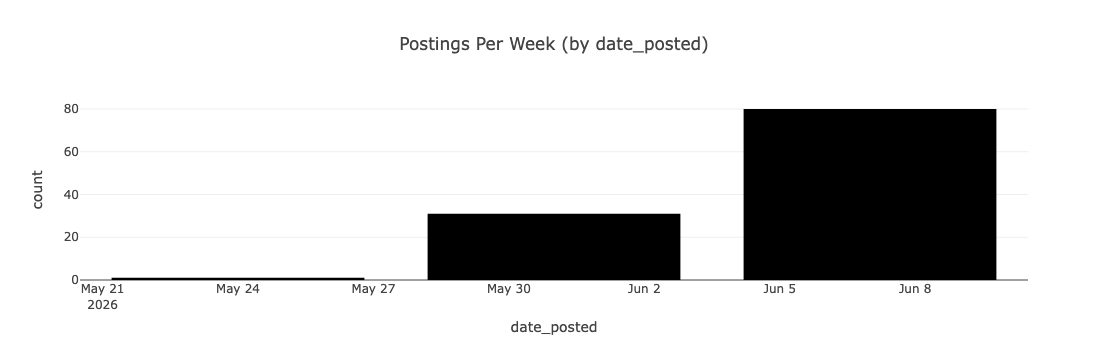

In [18]:
# Date coverage
print("date_posted range:", df['date_posted'].min(), "->", df['date_posted'].max())
print("ingested_at range:", df['ingested_at'].min(), "->", df['ingested_at'].max())
print(f"Null date_posted: {df['date_posted'].isna().sum()}")

# Weekly postings
weekly = (
    df.dropna(subset=['date_posted'])
    .set_index('date_posted')
    .resample('W')
    .size()
    .reset_index(name='count')
)
fig = px.bar(weekly, x='date_posted', y='count', title='Postings Per Week (by date_posted)')
fig.show()

## 7. Decisions — what makes the Market Insights page?

(Fill in after running the above)

- [ ] Salary box plot by archetype: **YES / NO / MAYBE**
- [ ] Top-N required tech bar chart: **YES / NO / MAYBE**
- [ ] Work model breakdown: **YES / NO / MAYBE**
- [ ] Title inflation rate / gauge: **YES / NO / MAYBE**
- [ ] Posting trend over time: **YES / NO / MAYBE**
- [ ] Tech stack heatmap by archetype: **YES / NO / MAYBE**
